<p align="right"><a href="./C3_W3_A1_Assignment.ipynb">English</a> | <strong>中文</strong></p>

# Deep Q-Learning —— 月球着陆器（Lunar Lander）

在本作业中，你将训练一个智能体（agent），让它把月球着陆器安全地降落在月球表面的着陆平台上。

# 大纲
- [ 1 - 导入库 <img align="Right" src="./images/lunar_lander.gif" width = 60% >](#1)
- [ 2 - 超参数](#2)
- [ 3 - 月球着陆器环境](#3)
  - [ 3.1 动作空间](#3.1)
  - [ 3.2 观测空间](#3.2)
  - [ 3.3 奖励](#3.3)
  - [ 3.4 回合终止](#3.4)
- [ 4 - 加载环境](#4)
- [ 5 - 与 Gym 环境交互](#5)
    - [ 5.1 探索环境的动力学](#5.1)
- [ 6 - Deep Q-Learning](#6)
  - [ 6.1 目标网络 Target Network](#6.1)
    - [ 练习 Exercise 1](#ex01)
  - [ 6.2 经验回放 Experience Replay](#6.2)
- [ 7 - 带经验回放的 Deep Q-Learning 算法](#7)
  - [ 练习 Exercise 2](#ex02)
- [ 8 - 更新网络权重](#8)
- [ 9 - 训练智能体](#9)
- [ 10 - 观看训练好的智能体的表现](#10)
- [ 11 - 恭喜！](#11)
- [ 12 - 参考文献](#12)

_**注意：** 为避免自动评分器（autograder）出错，你不能编辑或删除本实验中的非评分 cell，也请不要新增任何 cell。
**当你通过本作业后**，如果想对其中的非评分代码做实验，可以按 notebook 底部的说明操作。_

<a name="1"></a>
## 1 - 导入库

我们会用到以下这些库：
- `numpy` 是 Python 中科学计算的库。
- `deque` 将作为我们记忆缓冲区（memory buffer）的数据结构。
- `namedtuple` 用来存储经验元组（experience tuples）。
- `gym` 工具包是一批可用于测试强化学习算法的环境集合。要注意本 notebook 用的是 `gym` 的 `0.24.0` 版本。
- `PIL.Image` 和 `pyvirtualdisplay` 用于渲染月球着陆器环境。
- 我们会用 `tensorflow.keras` 框架里的若干模块来构建深度学习模型。
- `utils` 是一个包含本作业辅助函数的模块，你不需要修改这个文件里的代码。

运行下面的 cell 来导入所有必需的库。

In [1]:
import time
from collections import deque, namedtuple

import gym
import numpy as np
import PIL.Image
import tensorflow as tf
import utils

from pyvirtualdisplay import Display
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.losses import MSE
from tensorflow.keras.optimizers import Adam

In [2]:
# Set up a virtual display to render the Lunar Lander environment.
Display(visible=0, size=(840, 480)).start();

# Set the random seed for TensorFlow
tf.random.set_seed(utils.SEED)

<a name="2"></a>
## 2 - 超参数

运行下面的 cell 来设置超参数。

In [3]:
MEMORY_SIZE = 100_000     # size of memory buffer
GAMMA = 0.995             # discount factor
ALPHA = 1e-3              # learning rate  
NUM_STEPS_FOR_UPDATE = 4  # perform a learning update every C time steps

<a name="3"></a>
## 3 - 月球着陆器环境

在本 notebook 中，我们会用 [OpenAI 的 Gym 库](https://www.gymlibrary.dev/)。Gym 库提供了各种各样用于强化学习的环境。简单说，一个环境（environment）代表一个待解决的问题或任务。在本 notebook 中，我们会尝试用强化学习来求解月球着陆器环境。

月球着陆器环境的目标是把月球着陆器安全地降落在月球表面的着陆平台上。着陆平台由两根旗杆标出，其中心位于坐标 `(0,0)`，不过着陆器也允许降落在着陆平台之外。着陆器从环境顶部中央出发，其质心被施加一个随机的初始力，且燃料无限。若你拿到 `200` 分，就认为这个环境被解决了。

<br>
<br>
<figure>
  <img src = "images/lunar_lander.gif" width = 40%>
      <figcaption style = "text-align: center; font-style: italic">图 1. 月球着陆器环境。</figcaption>
</figure>



<a name="3.1"></a>
### 3.1 动作空间 Action Space

智能体有四个可用的离散动作：

* 什么都不做。
* 点燃右侧引擎。
* 点燃主引擎。
* 点燃左侧引擎。

每个动作有一个对应的数值：

```python
Do nothing = 0
Fire right engine = 1
Fire main engine = 2
Fire left engine = 3
```

<a name="3.2"></a>
### 3.2 观测空间 Observation Space

智能体的观测空间由一个含 8 个变量的状态向量组成：

* 它的 $(x,y)$ 坐标。着陆平台始终位于坐标 $(0,0)$。
* 它的线速度 $(\dot x,\dot y)$。
* 它的角度 $\theta$。
* 它的角速度 $\dot \theta$。
* 两个布尔量 $l$ 和 $r$，表示每条支腿是否与地面接触。

<a name="3.3"></a>
### 3.3 奖励 Rewards

每一步之后都会给出一个奖励。一个回合（episode）的总奖励是该回合内所有步奖励之和。

对每一步，奖励：
- 着陆器离着陆平台越近/越远，奖励越增/越减。
- 着陆器移动越慢/越快，奖励越增/越减。
- 着陆器越倾斜（角度偏离水平），奖励越减。
- 每有一条支腿接触地面，奖励增加 10 分。
- 侧引擎每点燃一帧，奖励减少 0.03 分。
- 主引擎每点燃一帧，奖励减少 0.3 分。

回合还会因坠毁或安全着陆分别获得 -100 或 +100 分的额外奖励。

<a name="3.4"></a>
### 3.4 回合终止 Episode Termination

一个回合结束（即环境进入终止状态），如果：

* 月球着陆器坠毁（即着陆器机身接触到月球表面）。

* 着陆器 $x$ 坐标的绝对值大于 1（即它越过了左边界或右边界）

你可以查看 [Open AI Gym 文档](https://www.gymlibrary.dev/environments/box2d/lunar_lander/) 获取该环境的完整描述。

<a name="4"></a>
## 4 - 加载环境

我们先用 `gym` 库的 `.make()` 方法加载 `LunarLander-v2` 环境。`LunarLander-v2` 是月球着陆器环境的最新版本，你可以在 [Open AI Gym 文档](https://www.gymlibrary.dev/environments/box2d/lunar_lander/#version-history) 里读到它的版本历史。

In [4]:
env = gym.make('LunarLander-v2')

加载环境后，我们用 `.reset()` 方法把环境重置到初始状态。着陆器从环境顶部中央出发，我们可以用 `.render()` 方法渲染环境的第一帧。

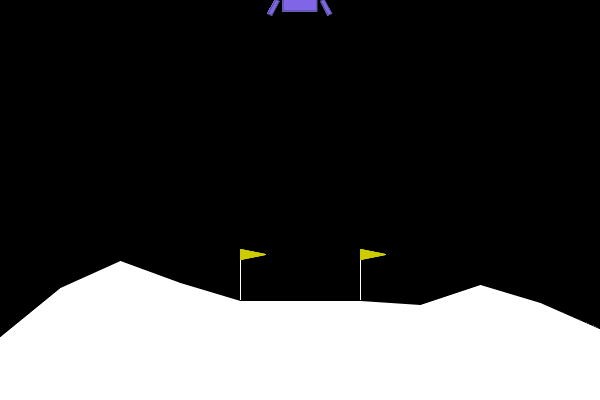

In [5]:
env.reset()
PIL.Image.fromarray(env.render(mode='rgb_array'))

为了稍后构建我们的神经网络，我们需要知道状态向量的大小和有效动作的数量。我们可以分别用 `.observation_space.shape` 和 `action_space.n` 方法从环境里获取这些信息。

In [6]:
state_size = env.observation_space.shape
num_actions = env.action_space.n

print('State Shape:', state_size)
print('Number of actions:', num_actions)

State Shape: (8,)
Number of actions: 4


<a name="5"></a>
## 5 - 与 Gym 环境交互

Gym 库实现了标准的 "智能体-环境循环（agent-environment loop）" 范式：

<br>
<center>
<video src = "./videos/rl_formalism.m4v" width="840" height="480" controls autoplay loop poster="./images/rl_formalism.png"> </video>
<figcaption style = "text-align:center; font-style:italic">图 2. 智能体-环境循环范式。</figcaption>
</center>
<br>

在标准的 "智能体-环境循环" 范式里，智能体在离散时间步 $t=0,1,2,...$ 与环境交互。在每个时间步 $t$，智能体基于它对环境状态 $S_t$ 的观测、用一个策略（policy）$\pi$ 来选择一个动作 $A_t$。智能体收到一个数值奖励 $R_t$，并在下一个时间步转移到一个新状态 $S_{t+1}$。

<a name="5.1"></a>
### 5.1 探索环境的动力学

在 Open AI 的 Gym 环境里，我们用 `.step()` 方法来运行环境动力学的单个时间步。在我们所用的 `gym` 版本里，`.step()` 方法接收一个动作，并返回四个值：

* `observation`（**object**）：一个环境特定的对象，表示你对环境的观测。在月球着陆器环境里，这对应一个 numpy 数组，包含着陆器的位置和速度，如 [3.2 观测空间](#3.2) 一节所述。


* `reward`（**float**）：因执行给定动作而返回的奖励量。在月球着陆器环境里，这对应一个 `numpy.float64` 类型的浮点数，如 [3.3 奖励](#3.3) 一节所述。


* `done`（**boolean**）：当 done 为 `True` 时，表示回合已终止，该重置环境了。


* `info`（**dictionary**）：对调试有用的诊断信息。本 notebook 不会用到这个变量，这里列出只是为了完整。

要开始一个回合，我们需要把环境重置到初始状态。我们用 `.reset()` 方法来做这件事。

In [7]:
# Reset the environment and get the initial state.
current_state = env.reset()

环境重置后，智能体就可以用 `.step()` 方法开始在环境里执行动作了。注意，智能体每个时间步只能执行一个动作。

在下面的 cell 里，你可以选不同的动作，看返回值如何随所执行动作而变化。记住，在这个环境里智能体有四个可用的离散动作，我们在代码里用它们对应的数值来指定：

```python
Do nothing = 0
Fire right engine = 1
Fire main engine = 2
Fire left engine = 3
```

In [8]:
# Select an action
action = 0

# Run a single time step of the environment's dynamics with the given action.
next_state, reward, done, _ = env.step(action)

# Display table with values.
utils.display_table(current_state, action, next_state, reward, done)

# Replace the `current_state` with the state after the action is taken
current_state = next_state

实践中，训练智能体时我们会用一个循环，让智能体在一个回合内连续执行许多动作。

<a name="6"></a>
## 6 - Deep Q-Learning

当状态空间和动作空间都是离散的时候，我们可以用 Bellman 方程迭代地估计动作价值函数（action-value function）：

$$
Q_{i+1}(s,a) = R + \gamma \max_{a'}Q_i(s',a')
$$

当 $i\to\infty$ 时，这个迭代方法会收敛到最优动作价值函数 $Q^*(s,a)$。这意味着智能体只需逐步探索状态-动作空间，并不断更新对 $Q(s,a)$ 的估计，直到它收敛到最优动作价值函数 $Q^*(s,a)$。然而，当状态空间是连续的时候，探索整个状态-动作空间在实践中就变得几乎不可能。因此，这也使得逐步估计 $Q(s,a)$ 直到它收敛到 $Q^*(s,a)$ 在实践中几乎不可能。

在 Deep $Q$-Learning 里，我们用一个神经网络来估计动作价值函数 $Q(s,a)\approx Q^*(s,a)$，从而解决这个问题。我们把这个神经网络称为 $Q$-Network，它可以通过在每次迭代调整权重、以最小化 Bellman 方程里的均方误差来训练。

不幸的是，在强化学习里用神经网络来估计动作价值函数，已被证明是高度不稳定的。幸运的是，有几种技术可以用来避免不稳定。这些技术包括使用 ***目标网络（Target Network）*** 和 ***经验回放（Experience Replay）***。我们会在接下来的小节里探讨这两种技术。

<a name="6.1"></a>
### 6.1 目标网络 Target Network

我们可以在每次迭代调整 $Q$-Network 的权重、以最小化 Bellman 方程里的均方误差来训练它，其中目标值（target values）由下式给出：

$$
y = R + \gamma \max_{a'}Q(s',a';w)
$$

其中 $w$ 是 $Q$-Network 的权重。这意味着我们在每次迭代调整权重 $w$，以最小化下面的误差：

$$
\overbrace{\underbrace{R + \gamma \max_{a'}Q(s',a'; w)}_{\rm {y~target}} - Q(s,a;w)}^{\rm {Error}}
$$

注意这构成了一个问题，因为 $y$ 目标在每次迭代都在变。目标不停移动会导致振荡和不稳定。为避免这一点，我们可以创建一个单独的神经网络来生成 $y$ 目标。我们把这个单独的神经网络称为 **目标 $\hat Q$-Network**，它将与原始 $Q$-Network 具有相同的架构。用了目标 $\hat Q$-Network 后，上面的误差变为：

$$
\overbrace{\underbrace{R + \gamma \max_{a'}\hat{Q}(s',a'; w^-)}_{\rm {y~target}} - Q(s,a;w)}^{\rm {Error}}
$$

其中 $w^-$ 和 $w$ 分别是目标 $\hat Q$-Network 和 $Q$-Network 的权重。

实践中，我们会用以下算法：每隔 $C$ 个时间步，我们用 $\hat Q$-Network 来生成 $y$ 目标，并用 $Q$-Network 的权重来更新目标 $\hat Q$-Network 的权重。我们会用一种 **软更新（soft update）** 来更新目标 $\hat Q$-Network 的权重 $w^-$。这意味着我们用下面的规则来更新权重 $w^-$：

$$
w^-\leftarrow \tau w + (1 - \tau) w^-
$$

其中 $\tau\ll 1$。通过软更新，我们确保目标值 $y$ 变化缓慢，这极大地改善了我们学习算法的稳定性。

<a name="ex01"></a>
### 练习 Exercise 1

在本练习中，你将创建 $Q$ 网络和目标 $\hat Q$ 网络，并设置优化器。记住，Deep $Q$-Network（DQN）是一个逼近动作价值函数 $Q(s,a)\approx Q^*(s,a)$ 的神经网络。它通过学习如何把状态映射到 $Q$ 值来做到这一点。

为求解月球着陆器环境，我们将采用具有以下架构的 DQN：

* 一个 `Input` 层，接收 `state_size` 作为输入。

* 一个有 `64` 个单元、`relu` 激活函数的 `Dense` 层。

* 一个有 `64` 个单元、`relu` 激活函数的 `Dense` 层。

* 一个有 `num_actions` 个单元、`linear` 激活函数的 `Dense` 层。这将是我们网络的输出层。


在下面的 cell 里，你应该用上面描述的模型架构来创建 $Q$-Network 和目标 $\hat Q$-Network。记住 $Q$-Network 和目标 $\hat Q$-Network 具有相同的架构。

最后，你应该把 `Adam` 设为优化器，学习率等于 `ALPHA`。回忆一下 `ALPHA` 是在 [超参数](#2) 一节里定义的。要注意，本练习中你应使用已经导入的这些包：
```python
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
```

In [10]:
# UNQ_C1
# GRADED CELL

# Create the Q-Network
q_network = Sequential([
    ### START CODE HERE ### 
    Input(shape=state_size),                      
    Dense(units=64, activation='relu'),            
    Dense(units=64, activation='relu'),            
    Dense(units=num_actions, activation='linear'),
    ### END CODE HERE ### 
    ])

# Create the target Q^-Network
target_q_network = Sequential([
    ### START CODE HERE ### 
    Input(shape=state_size),                       
    Dense(units=64, activation='relu'),            
    Dense(units=64, activation='relu'),            
    Dense(units=num_actions, activation='linear'), 
    ### END CODE HERE ###
    ])

### START CODE HERE ### 
optimizer = Adam(learning_rate=ALPHA)
### END CODE HERE ###

In [11]:
# UNIT TEST
from public_tests import *

test_network(q_network)
test_network(target_q_network)
test_optimizer(optimizer, ALPHA) 

All tests passed!
All tests passed!
All tests passed!


<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>

```python
# Create the Q-Network
q_network = Sequential([
    Input(shape=state_size),
    Dense(units=64, activation='relu'),
    Dense(units=64, activation='relu'),
    Dense(units=num_actions, activation='linear'),
    ])

# Create the target Q^-Network
target_q_network = Sequential([
    Input(shape=state_size),
    Dense(units=64, activation='relu'),
    Dense(units=64, activation='relu'),
    Dense(units=num_actions, activation='linear'),
    ])

optimizer = Adam(learning_rate=ALPHA)
``` 

<a name="6.2"></a>
### 6.2 经验回放 Experience Replay

当智能体与环境交互时，它经历的状态、动作和奖励本质上是顺序（sequential）的。如果智能体试图从这些连续的经验中学习，会因为它们之间的强相关性而遇到问题。为避免这一点，我们采用一种叫 **经验回放（Experience Replay）** 的技术，为训练智能体生成不相关的经验。经验回放包括：把智能体的经验（即它收到的状态、动作和奖励）存到一个记忆缓冲区里，然后从缓冲区随机采样一个 mini-batch 的经验来做学习。经验元组 $(S_t, A_t, R_t, S_{t+1})$ 会在智能体与环境交互时、于每个时间步被加入记忆缓冲区。

为方便起见，我们会把经验存为具名元组（named tuples）。

In [12]:
# Store experiences as named tuples
experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])

通过使用经验回放，我们避免了有问题的相关性、振荡和不稳定。此外，经验回放还让智能体有可能在多次权重更新中使用同一条经验，这提高了数据效率。

<a name="7"></a>
## 7 - 带经验回放的 Deep Q-Learning 算法

既然我们已经了解了将要用到的所有技术，就可以把它们组合起来，得到带经验回放的 Deep Q-Learning 算法。
<br>
<br>
<figure>
  <img src = "images/deep_q_algorithm.png" width = 90% style = "border: thin silver solid; padding: 0px">
      <figcaption style = "text-align: center; font-style: italic">图 3. 带经验回放的 Deep Q-Learning。</figcaption>
</figure>

<a name="ex02"></a>
### 练习 Exercise 2

在本练习中，你将实现上面 *图 3* 所列算法的第 ***12*** 行，你还要计算 $y$ 目标与 $Q(s,a)$ 值之间的损失。在下面的 cell 里，通过把 $y$ 目标设为下式来补全 `compute_loss` 函数：

$$
\begin{equation}
    y_j =
    \begin{cases}
      R_j & \text{if episode terminates at step  } j+1\\
      R_j + \gamma \max_{a'}\hat{Q}(s_{j+1},a') & \text{otherwise}\\
    \end{cases}
\end{equation}
$$

这里有几点要注意：

* `compute_loss` 函数接收一个 mini-batch 的经验元组。这个 mini-batch 的经验元组被解包，取出 `states`、`actions`、`rewards`、`next_states` 和 `done_vals`。你要记住这些变量是 *TensorFlow 张量（Tensors）*，其大小取决于 mini-batch 的大小。例如，若 mini-batch 大小为 `64`，那么 `rewards` 和 `done_vals` 都会是含 `64` 个元素的 TensorFlow 张量。


* 当变量是含许多元素的张量时，用 `if/else` 语句来设置 $y$ 目标是行不通的。但注意，你可以用 `done_vals` 在一行代码里实现上面的逻辑。为此，回忆一下 `done` 变量是一个布尔变量，当回合在第 $j+1$ 步终止时取值 `True`，否则取值 `False`。考虑到布尔值 `True` 的数值是 `1`、布尔值 `False` 的数值是 `0`，你可以用因子 `(1 - done_vals)` 在一行代码里实现上面的逻辑。给个提示：注意 `(1 - done_vals)` 在 `done_vals` 为 `True` 时值为 `0`、在 `done_vals` 为 `False` 时值为 `1`。

最后，通过计算 `y_targets` 和 `q_values` 之间的均方误差（`MSE`）来计算损失。为计算均方误差，你应使用已经导入的包 `MSE`：
```python
from tensorflow.keras.losses import MSE
```

In [15]:
# UNQ_C2
# GRADED FUNCTION: calculate_loss

def compute_loss(experiences, gamma, q_network, target_q_network):
    """ 
    Calculates the loss.
    
    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
      q_network: (tf.keras.Sequential) Keras model for predicting the q_values
      target_q_network: (tf.keras.Sequential) Keras model for predicting the targets
          
    Returns:
      loss: (TensorFlow Tensor(shape=(0,), dtype=int32)) the Mean-Squared Error between
            the y targets and the Q(s,a) values.
    """

    # Unpack the mini-batch of experience tuples
    states, actions, rewards, next_states, done_vals = experiences
    
    # Compute max Q^(s,a)
    max_qsa = tf.reduce_max(target_q_network(next_states), axis=-1)
    
    # Set y = R if episode terminates, otherwise set y = R + γ max Q^(s,a).
    ### START CODE HERE ### 
    y_targets = rewards + (gamma * max_qsa * (1 - done_vals))
    ### END CODE HERE ###
    
    # Get the q_values and reshape to match y_targets
    q_values = q_network(states)
    q_values = tf.gather_nd(q_values, tf.stack([tf.range(q_values.shape[0]),
                                                tf.cast(actions, tf.int32)], axis=1))
        
    # Compute the loss
    ### START CODE HERE ### 
    loss = MSE(y_targets, q_values) 
    ### END CODE HERE ### 
    
    return loss

In [16]:
# UNIT TEST    
test_compute_loss(compute_loss)

All tests passed!


<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>

```python
def compute_loss(experiences, gamma, q_network, target_q_network):
    """
    Calculates the loss.

    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
      q_network: (tf.keras.Sequential) Keras model for predicting the q_values
      target_q_network: (tf.keras.Sequential) Keras model for predicting the targets

    Returns:
      loss: (TensorFlow Tensor(shape=(0,), dtype=int32)) the Mean-Squared Error between
            the y targets and the Q(s,a) values.
    """


    # Unpack the mini-batch of experience tuples
    states, actions, rewards, next_states, done_vals = experiences

    # Compute max Q^(s,a)
    max_qsa = tf.reduce_max(target_q_network(next_states), axis=-1)

    # Set y = R if episode terminates, otherwise set y = R + γ max Q^(s,a).
    y_targets = rewards + (gamma * max_qsa * (1 - done_vals))

    # Get the q_values
    q_values = q_network(states)
    q_values = tf.gather_nd(q_values, tf.stack([tf.range(q_values.shape[0]),
                                                tf.cast(actions, tf.int32)], axis=1))

    # Calculate the loss
    loss = MSE(y_targets, q_values)

    return loss

``` 

<a name="8"></a>
## 8 - 更新网络权重

我们会用下面的 `agent_learn` 函数来实现 [图 3](#7) 所列算法的第 ***12 - 14*** 行。`agent_learn` 函数会用一个自定义训练循环来更新 $Q$ 和目标 $\hat Q$ 网络的权重。因为我们用的是自定义训练循环，需要通过一个 `tf.GradientTape` 实例来取得梯度，然后调用 `optimizer.apply_gradients()` 来更新 $Q$-Network 的权重。注意，我们还用了 `@tf.function` 装饰器来提升性能。没有这个装饰器，我们的训练会花两倍的时间。如果你想更多了解如何用 `@tf.function` 提升性能，可以看看 [TensorFlow 文档](https://www.tensorflow.org/guide/function)。

这个函数的最后一行用 [软更新](#6.1) 来更新目标 $\hat Q$-Network 的权重。如果你想知道这在代码里是怎么实现的，我们鼓励你看看 `utils` 模块里的 `utils.update_target_network` 函数。

In [17]:
@tf.function
def agent_learn(experiences, gamma):
    """
    Updates the weights of the Q networks.
    
    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
    
    """
    
    # Calculate the loss
    with tf.GradientTape() as tape:
        loss = compute_loss(experiences, gamma, q_network, target_q_network)

    # Get the gradients of the loss with respect to the weights.
    gradients = tape.gradient(loss, q_network.trainable_variables)
    
    # Update the weights of the q_network.
    optimizer.apply_gradients(zip(gradients, q_network.trainable_variables))

    # update the weights of target q_network
    utils.update_target_network(q_network, target_q_network)

<a name="9"></a>
## 9 - 训练智能体

现在我们已准备好训练智能体来求解月球着陆器环境。在下面的 cell 里，我们会逐行实现 [图 3](#7) 的算法（注意，我们把同一算法也放在了下面以便参考，这样你就不用在 notebook 里上下滚动了）：

* **第 1 行**：我们把 `memory_buffer` 初始化为容量 $N =$ `MEMORY_SIZE`。注意我们用 `deque` 作为 `memory_buffer` 的数据结构。


* **第 2 行**：我们跳过这一行，因为已经在 [练习 Exercise 1](#ex01) 里初始化了 `q_network`。


* **第 3 行**：我们把 `target_q_network` 的权重设为与 `q_network` 相等，以此初始化它。


* **第 4 行**：我们开始外层循环。注意我们设了 $M =$ `num_episodes = 2000`。这个数字是合理的，因为用本 notebook 的默认参数，智能体应该能在少于 `2000` 个回合内求解月球着陆器环境。


* **第 5 行**：我们用 `.reset()` 方法把环境重置到初始状态，并获取初始状态。


* **第 6 行**：我们开始内层循环。注意我们设了 $T =$ `max_num_timesteps = 1000`。这意味着如果回合在 `1000` 个时间步后还没终止，它就会自动终止。


* **第 7 行**：智能体观测当前 `state`，并用一个 $\epsilon$-贪婪（$\epsilon$-greedy）策略来选择一个 `action`。我们的智能体一开始用 $\epsilon =$ `epsilon = 1`，这产生一个等价于等概率随机策略的 $\epsilon$-贪婪策略。这意味着在训练开始时，智能体无论观测到什么 `state` 都只是执行随机动作。随着训练推进，我们会用一个给定的 $\epsilon$ 衰减率把 $\epsilon$ 的值缓慢地降向一个最小值。我们希望这个最小值接近零，因为 $\epsilon = 0$ 会产生一个等价于贪婪策略的 $\epsilon$-贪婪策略。这意味着到训练接近尾声时，智能体会倾向于选择它（基于过去经验）认为能最大化 $Q(s,a)$ 的 `action`。我们会把最小 $\epsilon$ 值设为 `0.01` 而不是恰好为 0，因为我们总想在训练中保留一点点探索。如果你想知道这在代码里是怎么实现的，我们鼓励你看看 `utils` 模块里的 `utils.get_action` 函数。


* **第 8 行**：我们用 `.step()` 方法在环境里执行给定的 `action`，并获取 `reward` 和 `next_state`。


* **第 9 行**：我们把 `experience(state, action, reward, next_state, done)` 元组存进 `memory_buffer`。注意我们也存了 `done` 变量，以便追踪回合何时终止。这让我们能在 [练习 Exercise 2](#ex02) 里设置 $y$ 目标。


* **第 10 行**：我们检查是否满足执行一次学习更新的条件。我们用自定义的 `utils.check_update_conditions` 函数来做这件事。这个函数检查是否已经过了 $C =$ `NUM_STEPS_FOR_UPDATE = 4` 个时间步、以及我们的 `memory_buffer` 是否有足够的经验元组来填满一个 mini-batch。例如，若 mini-batch 大小为 `64`，那么我们的 `memory_buffer` 应有超过 `64` 个经验元组才能通过后一个条件。若条件满足，`utils.check_update_conditions` 函数会返回 `True`，否则返回 `False`。


* **第 11 - 14 行**：如果 `update` 变量为 `True`，我们就执行一次学习更新。学习更新包括：从 `memory_buffer` 随机采样一个 mini-batch 的经验元组、设置 $y$ 目标、执行梯度下降、更新网络权重。我们会用 [第 8 节](#8) 里定义的 `agent_learn` 函数来完成后三步。


* **第 15 行**：在内层循环每次迭代结束时，我们把 `next_state` 设为新的 `state`，以便循环能从这个新状态重新开始。此外，我们检查回合是否到达了终止状态（即检查 `done = True`）。若到达了终止状态，就跳出内层循环。


* **第 16 行**：在外层循环每次迭代结束时，我们更新 $\epsilon$ 的值，并检查环境是否已被解决。若智能体在最后 `100` 个回合里平均得到 `200` 分，我们就认为环境已被解决。若环境还没被解决，我们就继续外层循环、开始一个新回合。

最后，我们想说明一下，我们额外加了一些变量来追踪智能体在每个回合里得到的总分。这会帮我们判断智能体是否已解决环境，也能让我们看到智能体在训练中的表现。我们还用 `time` 模块来测量训练花了多长时间。

<br>
<br>
<figure>
  <img src = "images/deep_q_algorithm.png" width = 90% style = "border: thin silver solid; padding: 0px">
      <figcaption style = "text-align: center; font-style: italic">图 4. 带经验回放的 Deep Q-Learning。</figcaption>
</figure>
<br>

**注意：** 用本 notebook 的默认参数，下面这个 cell 运行需要 10 到 15 分钟。

In [ ]:
start = time.time()

num_episodes = 2000
max_num_timesteps = 1000

total_point_history = []

num_p_av = 100    # number of total points to use for averaging
epsilon = 1.0     # initial ε value for ε-greedy policy

# Create a memory buffer D with capacity N
memory_buffer = deque(maxlen=MEMORY_SIZE)

# Set the target network weights equal to the Q-Network weights
target_q_network.set_weights(q_network.get_weights())

for i in range(num_episodes):
    
    # Reset the environment to the initial state and get the initial state
    state = env.reset()
    total_points = 0
    
    for t in range(max_num_timesteps):
        
        # From the current state S choose an action A using an ε-greedy policy
        state_qn = np.expand_dims(state, axis=0)  # state needs to be the right shape for the q_network
        q_values = q_network(state_qn)
        action = utils.get_action(q_values, epsilon)
        
        # Take action A and receive reward R and the next state S'
        next_state, reward, done, _ = env.step(action)
        
        # Store experience tuple (S,A,R,S') in the memory buffer.
        # We store the done variable as well for convenience.
        memory_buffer.append(experience(state, action, reward, next_state, done))
        
        # Only update the network every NUM_STEPS_FOR_UPDATE time steps.
        update = utils.check_update_conditions(t, NUM_STEPS_FOR_UPDATE, memory_buffer)
        
        if update:
            # Sample random mini-batch of experience tuples (S,A,R,S') from D
            experiences = utils.get_experiences(memory_buffer)
            
            # Set the y targets, perform a gradient descent step,
            # and update the network weights.
            agent_learn(experiences, GAMMA)
        
        state = next_state.copy()
        total_points += reward
        
        if done:
            break
            
    total_point_history.append(total_points)
    av_latest_points = np.mean(total_point_history[-num_p_av:])
    
    # Update the ε value
    epsilon = utils.get_new_eps(epsilon)

    print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}", end="")

    if (i+1) % num_p_av == 0:
        print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}")

    # We will consider that the environment is solved if we get an
    # average of 200 points in the last 100 episodes.
    if av_latest_points >= 200.0:
        print(f"\n\nEnvironment solved in {i+1} episodes!")
        q_network.save('lunar_lander_model.h5')
        break
        
tot_time = time.time() - start

print(f"\nTotal Runtime: {tot_time:.2f} s ({(tot_time/60):.2f} min)")

Episode 100 | Total point average of the last 100 episodes: -150.85
Episode 200 | Total point average of the last 100 episodes: -106.11
Episode 243 | Total point average of the last 100 episodes: -106.82

我们可以把总分历史连同移动平均一起画出来，看看智能体在训练中如何进步。如果你想了解 `utils.plot_history` 函数里可用的不同绘图选项，我们鼓励你看看 `utils` 模块。

In [ ]:
# Plot the total point history along with the moving average
utils.plot_history(total_point_history)

<a name="10"></a>
## 10 - 观看训练好的智能体的表现

既然我们已经训练好了智能体，就可以看看它的实际表现。我们会用 `utils.create_video` 函数，用训练好的 $Q$-Network 来创建一段智能体与环境交互的视频。`utils.create_video` 函数用 `imageio` 库来创建视频。这个库会产生一些可能干扰注意力的警告，所以为了抑制这些警告，我们运行下面的代码。

In [ ]:
# Suppress warnings from imageio
import logging
logging.getLogger().setLevel(logging.ERROR)

在下面的 cell 里，我们用训练好的 `q_network` 创建一段智能体与月球着陆器环境交互的视频。视频以给定的 `filename` 保存到 `videos` 文件夹。我们用 `utils.embed_mp4` 函数把视频嵌入 Jupyter Notebook，这样我们就能直接在这里看，而不必下载。

要注意，由于月球着陆器一开始其质心被施加了一个随机的初始力，每次运行下面的 cell 你都会看到一段不同的视频。如果智能体训练得当，它应该每次都能把月球着陆器降落在着陆平台上，无论质心被施加了怎样的初始力。

In [ ]:
filename = "./videos/lunar_lander.mp4"

utils.create_video(filename, env, q_network)
utils.embed_mp4(filename)

<a name="11"></a>
## 11 - 恭喜！

你已经成功地用带经验回放的 Deep Q-Learning 训练了一个智能体，让它把月球着陆器安全地降落在月球表面的着陆平台上。恭喜！

<a name="12"></a>
## 12 - 参考文献

如果你想更多了解 Deep Q-Learning，我们推荐你查阅以下论文。


* Mnih, V., Kavukcuoglu, K., Silver, D. et al. Human-level control through deep reinforcement learning. Nature 518, 529–533 (2015).


* Lillicrap, T. P., Hunt, J. J., Pritzel, A., et al. Continuous Control with Deep Reinforcement Learning. ICLR (2016).


* Mnih, V., Kavukcuoglu, K., Silver, D. et al. Playing Atari with Deep Reinforcement Learning. arXiv e-prints.  arXiv:1312.5602 (2013).

<details>
  <summary><font size="2" color="darkgreen"><b>如果你想对其中的非评分代码做实验，请点击这里。</b></font></summary>
    <p><i><b>重要提示：请务必在你已经通过本作业后再这样做，以免影响自动评分器。</b></i>
    <ol>
        <li> 在 notebook 菜单，点击 “View” > “Cell Toolbar” > “Edit Metadata”</li>
        <li> 点击你想锁定/解锁的 code cell 旁边的 “Edit Metadata” 按钮</li>
        <li> 把 “editable” 属性值设为：
            <ul>
                <li> “true” 表示解锁 </li>
                <li> “false” 表示锁定 </li>
            </ul>
        </li>
        <li> 在 notebook 菜单，点击 “View” > “Cell Toolbar” > “None” </li>
    </ol>
    <p> 下面是上述步骤的一个简短演示：
        <br>
        <img src="https://lh3.google.com/u/0/d/14Xy_Mb17CZVgzVAgq7NCjMVBvSae3xO1" align="center" alt="unlock_cells.gif">
</details>